In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\INTEL\OneDrive\Desktop\Coding\MACHINE LEARNING\Machine Learning\Salary Classification\Adult Salary.csv")

In [3]:
df.head()

,Age,Gender,WorkingClass,Education,MaritalStatus,Occupation,Relationship,Race,NativeCountry,Income
0,25,Male,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,United-States,<=50K
1,38,Male,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,United-States,<=50K
2,28,Male,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,United-States,>50K
3,44,Male,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,United-States,>50K
4,18,Female,?,Some-college,Never-married,?,Own-child,White,United-States,<=50K


In [4]:
df.tail()

,Age,Gender,WorkingClass,Education,MaritalStatus,Occupation,Relationship,Race,NativeCountry,Income
48837,27,Female,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,United-States,<=50K
48838,40,Male,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,United-States,>50K
48839,58,Female,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,United-States,<=50K
48840,22,Male,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,United-States,<=50K
48841,52,Female,Self-emp-inc,HS-grad,Married-civ-spouse,Exec-managerial,Wife,White,United-States,>50K


In [5]:
df.replace("?",pd.NA,inplace=True)

In [6]:
df.isnull().sum()

Age                 0
Gender              0
WorkingClass     2799
Education           0
MaritalStatus       0
Occupation       2809
Relationship        0
Race                0
NativeCountry     857
Income              0
dtype: int64

In [7]:
df.shape

(48842, 10)

In [8]:
df = df.dropna()

In [9]:
df.shape

(45222, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            45222 non-null  int64 
 1   Gender         45222 non-null  object
 2   WorkingClass   45222 non-null  object
 3   Education      45222 non-null  object
 4   MaritalStatus  45222 non-null  object
 5   Occupation     45222 non-null  object
 6   Relationship   45222 non-null  object
 7   Race           45222 non-null  object
 8   NativeCountry  45222 non-null  object
 9   Income         45222 non-null  object
dtypes: int64(1), object(9)
memory usage: 3.8+ MB


In [11]:
df.describe()

,Age
count,45222.000000
mean,38.547941
std,13.217870
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,90.000000


<Axes: xlabel='Income', ylabel='count'>

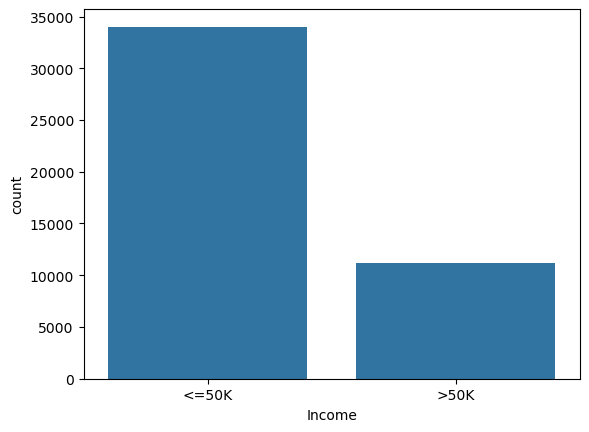

In [12]:
sns.countplot(x="Income", data=df)

In [13]:
df.columns

Index(['Age', 'Gender', 'WorkingClass', 'Education', 'MaritalStatus',
       'Occupation', 'Relationship', 'Race', 'NativeCountry', 'Income'],
      dtype='object')

In [17]:
df = df.drop(["MaritalStatus"],axis=1)

In [25]:
freq = df['NativeCountry'].value_counts()
rare_country = freq[freq<90].index
df['NativeCountry'] = df['NativeCountry'].replace(rare_country,"Other")

In [28]:
print(f"Frequency of {df['Gender'].value_counts()}\n")
print(f"Frequency of {df['Education'].value_counts()}\n")
print(f"Frequency of {df['Occupation'].value_counts()}\n")
print(f"Frequency of {df['Relationship'].value_counts()}\n")
print(f"Frequency of {df['Race'].value_counts()}\n")
print(f"Frequency of {df['NativeCountry'].value_counts()}\n")

Frequency of Gender
Male      30527
Female    14695
Name: count, dtype: int64

Frequency of Education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

Frequency of Occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales                5408
Other-service        4808
Machine-op-inspct    2970
Transport-moving     2316
Handlers-cleaners    2046
Farming-fishing      1480
Tech-support         1420
Protective-serv       976
Priv-house-serv       232
Armed-Forces           14
Name: count, dtype: int64

Frequency of Relationship
Husband           18666
Not-in-family     11702
Own-child          6626
Unmarr

In [29]:
x = df.drop(["Income"],axis = 1)
y = df['Income']

In [44]:
categorical_cols = x.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output = False)

from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("col", encoder, categorical_cols)
    ],
    remainder="passthrough"
)

x_encoded = preprocessor.fit_transform(x)
encoded_cols = preprocessor.get_feature_names_out()
x_encoded = pd.DataFrame(x_encoded, columns=encoded_cols)

In [45]:
x_encoded

,col__Gender_Male,col__WorkingClass_Local-gov,col__WorkingClass_Private,col__WorkingClass_Self-emp-inc,col__WorkingClass_Self-emp-not-inc,col__WorkingClass_State-gov,col__WorkingClass_Without-pay,col__Education_11th,col__Education_12th,col__Education_1st-4th,...,col__NativeCountry_India,col__NativeCountry_Italy,col__NativeCountry_Jamaica,col__NativeCountry_Mexico,col__NativeCountry_Other,col__NativeCountry_Philippines,col__NativeCountry_Puerto-Rico,col__NativeCountry_South,col__NativeCountry_United-States,remainder__Age
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,25.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,38.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,44.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,27.0
45218,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,40.0
45219,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,58.0
45220,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,22.0


In [46]:
x_encoded.columns

Index(['col__Gender_Male', 'col__WorkingClass_Local-gov',
       'col__WorkingClass_Private', 'col__WorkingClass_Self-emp-inc',
       'col__WorkingClass_Self-emp-not-inc', 'col__WorkingClass_State-gov',
       'col__WorkingClass_Without-pay', 'col__Education_11th',
       'col__Education_12th', 'col__Education_1st-4th',
       'col__Education_5th-6th', 'col__Education_7th-8th',
       'col__Education_9th', 'col__Education_Assoc-acdm',
       'col__Education_Assoc-voc', 'col__Education_Bachelors',
       'col__Education_Doctorate', 'col__Education_HS-grad',
       'col__Education_Masters', 'col__Education_Preschool',
       'col__Education_Prof-school', 'col__Education_Some-college',
       'col__Occupation_Armed-Forces', 'col__Occupation_Craft-repair',
       'col__Occupation_Exec-managerial', 'col__Occupation_Farming-fishing',
       'col__Occupation_Handlers-cleaners',
       'col__Occupation_Machine-op-inspct', 'col__Occupation_Other-service',
       'col__Occupation_Priv-house-ser

In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size = 0.2, random_state = 42)

In [49]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators = 100, max_leaf_nodes = 16, n_jobs = -1)
rnd_clf.fit(x_train, y_train)

RandomForestClassifier(max_leaf_nodes=16, n_jobs=-1)

In [67]:
importances = rnd_clf.feature_importances_
features = x_encoded.columns
pairs = list(zip(features,importances))
pairs.sort(key=lambda x: x[1], reverse=True)
for feature, importance in pairs:
    print(feature," : ",importance)

remainder__Age  :  0.17563591351547647
col__Relationship_Own-child  :  0.11104234601946096
col__Relationship_Not-in-family  :  0.1019300757562338
col__Occupation_Exec-managerial  :  0.09765238353833347
col__Gender_Male  :  0.08725717055057929
col__Occupation_Prof-specialty  :  0.07252368078237534
col__Education_Bachelors  :  0.06863996558788395
col__Relationship_Unmarried  :  0.04521585000928816
col__Education_Masters  :  0.04103210157578903
col__Occupation_Other-service  :  0.032507993046345635
col__Education_Prof-school  :  0.031204154718710433
col__Education_HS-grad  :  0.021174044491259352
col__Relationship_Wife  :  0.01858712860568149
col__Education_Doctorate  :  0.016066583780469074
col__WorkingClass_Self-emp-inc  :  0.015037552827150975
col__Relationship_Other-relative  :  0.011093048669155194
col__Occupation_Handlers-cleaners  :  0.007749221107533718
col__WorkingClass_Private  :  0.006609160654261821
col__Occupation_Sales  :  0.004551840742955979
col__Occupation_Machine-op-insp

In [50]:
from sklearn.model_selection import cross_val_score
a = cross_val_score(rnd_clf, x_train, y_train, cv = 4, scoring = "accuracy")
print(a)
print("Mean =",a.mean())

[0.81404091 0.80572755 0.81324635 0.803295  ]
Mean = 0.8090774535353114


In [54]:
model_pred = rnd_clf.predict(x_train)
model_pred

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      dtype=object)

In [55]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_train, model_pred)
print("Accuracy =",accuracy)

Accuracy = 0.8051524449235702


In [56]:
model_pred_test = rnd_clf.predict(x_test)
model_pred_test

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      dtype=object)

In [58]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, model_pred_test)
print("Accuracy =",accuracy)

Accuracy = 0.8159203980099502
